# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1 --rng-seed 42
```

# Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape, generate_shape_from_json
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
    plot_district_by_uid,
)
from word import PlanWordBuilder, WordStat
from scipy.cluster.hierarchy import dendrogram, linkage

square_side = 100
num_districts = 3

PRECINCT_FN = "data/networkx/l_grid_100x100_minus_50x50_3.json"
SAMPLE_FN = "local/output/lgrid100x100-50x50-3/atlas.jsonl.gz"
OUT_DIR = "local/output/lgrid100x100-50x50-3/processed"
# gdf = generate_grid_shape(square_side)
gdf = generate_shape_from_json(PRECINCT_FN)

is_huge = True if square_side > 4 else False

C:\Users\edzh0\anaconda3\envs\gmstrat\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(gdf.iloc[0])

id                                              0
precinct                                    (0,0)
population                                      1
geometry      POLYGON ((0 0, 1 0, 1 1, 0 1, 0 0))
Name: 0, dtype: object


In [2]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\lgrid100x100-50x50-3\atlas.jsonl.gz


plans: 100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6600.79it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [3]:
sp.df_districts.head()

,district_str,district_uid
0,0.1.2.3.4.5.6.7.8.9.10.11.12.13.14.15.16.17.18...,0
1,53.54.55.56.57.58.59.60.61.62.63.64.65.66.67.6...,1
2,3113.3114.3115.3212.3213.3214.3215.3216.3301.3...,2
3,31.32.33.34.35.36.37.38.39.40.41.42.43.44.45.4...,3
4,11.12.13.14.15.16.17.18.19.20.21.22.23.24.25.2...,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [4]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[0, 1, 2]",0.1.2
1,2000,1,atlas,"[3, 4, 5]",3.4.5
2,3000,2,atlas,"[6, 7, 8]",6.7.8
3,4000,3,atlas,"[9, 10, 11]",9.10.11
4,5000,4,atlas,"[12, 13, 14]",12.13.14


We visualize the first sampled plan and its first district

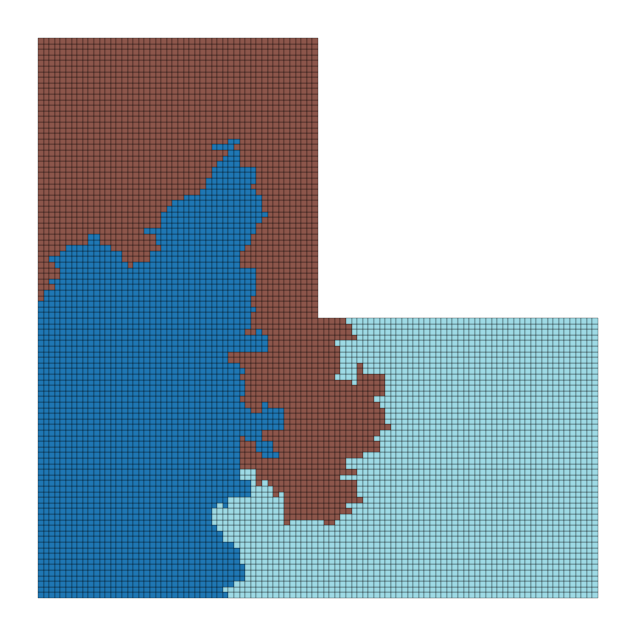

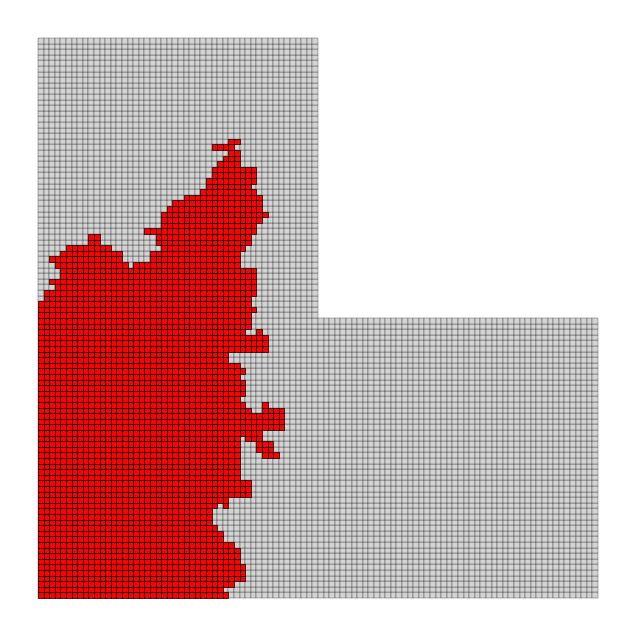

In [5]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [6]:
sp.load_distance_matrix()
sp.ensure_linkage()

num_letters = num_districts * 2
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  2%|█▊                                                                                           | 1/50 [00:00<00:20,  2.39it/s]

epoch 0: rel_improvement = 0.020916899931703845


  4%|███▋                                                                                         | 2/50 [00:00<00:20,  2.34it/s]

epoch 1: rel_improvement = 0.019941368501316233


  6%|█████▌                                                                                       | 3/50 [00:01<00:21,  2.18it/s]

epoch 2: rel_improvement = 0.019901580876660878


  8%|███████▍                                                                                     | 4/50 [00:01<00:20,  2.26it/s]

epoch 3: rel_improvement = 0.01540641792969973


  8%|███████▍                                                                                     | 4/50 [00:02<00:25,  1.79it/s]


We visualize some letters 

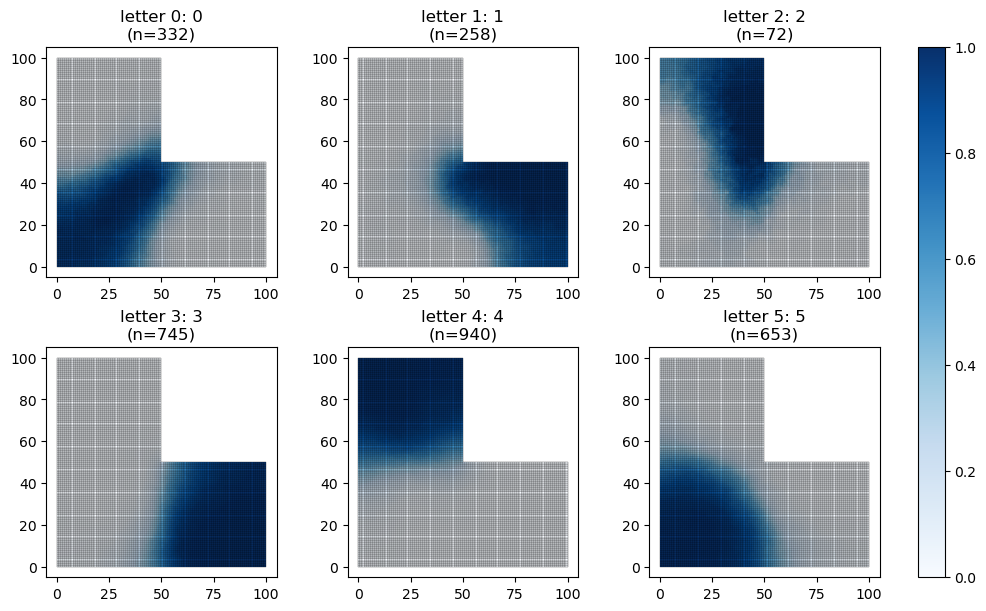

In [7]:
cluster_sizes = np.array([len(hc.c2i[i]) for i in range(num_letters)])

letters = list(range(num_letters))
plot_words_list(gdf, hc.cluster_densities, letters, cluster_sizes=cluster_sizes, cols=3, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [8]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|███████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9628.38it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1, 2]","[3, 4, 5]",3043.0,3043.0,0.1.2,3.4.5,28
1,0,"[0, 1, 2]","[2, 3, 5]",3058.0,3043.0,0.1.2,2.3.5,22
2,0,"[0, 1, 2]","[0, 3, 4]",3348.0,3043.0,0.1.2,0.3.4,7
3,0,"[0, 1, 2]","[0, 2, 3]",3363.0,3043.0,0.1.2,0.2.3,4
4,0,"[0, 1, 2]","[1, 4, 5]",3605.0,3043.0,0.1.2,1.4.5,17


We compute stationary distribution under some POU (controlled by temperature).

In [9]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,7,0.3.4,"[0, 3, 4]",0.099633
1,28,3.4.5,"[3, 4, 5]",0.099533
2,17,1.4.5,"[1, 4, 5]",0.098733


This is the flux matrix

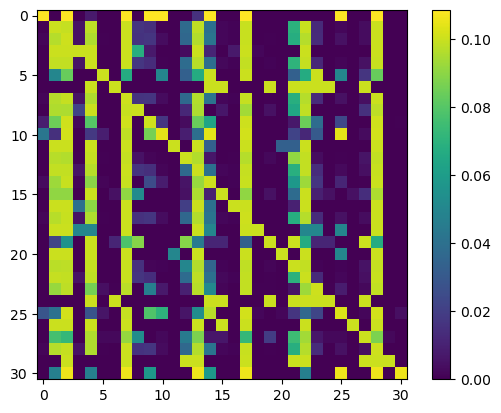

In [10]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

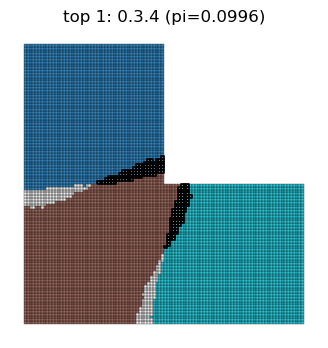

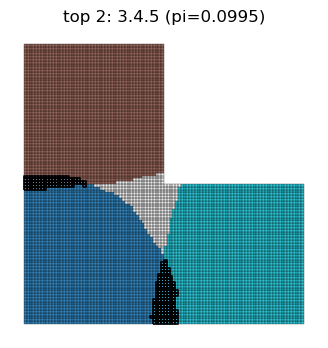

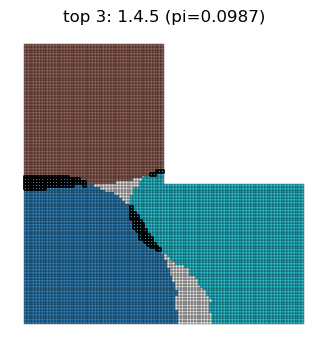

In [11]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()

Visualize dendrogram from sp linkage

In [12]:
def plot_dendrogram_from_linkage(Z, no_labels=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, ax=ax, no_labels=no_labels)
    ax.set_xlabel("District UID")
    ax.set_ylabel("Merge distance")
    ax.set_title("District clustering dendrogram")
    plt.tight_layout()
    plt.show()
if not is_huge:
    plot_dendrogram_from_linkage(np.load(sp.paths.linkage).astype(np.float64))

In [13]:
# Code by Claude Sonnet 4.6

Z = np.load(sp.paths.linkage).astype(np.float64)
n = int(Z.shape[0] + 1)

from collections import defaultdict

node_to_cluster = {}  # leaf -> cluster id
cluster_members = defaultdict(set)
cluster_first_dist = {}  # cluster id -> distance at which it was first formed
cluster_counter = 0

for i, (a, b, dist, size) in enumerate(Z):
    a, b = int(a), int(b)
    new_node = n + i

    a_leaves = cluster_members[a] if a >= n else {a}
    b_leaves = cluster_members[b] if b >= n else {b}
    cluster_members[new_node] = a_leaves | b_leaves

    a_assigned_leaves = {leaf for leaf in a_leaves if leaf in node_to_cluster}
    b_assigned_leaves = {leaf for leaf in b_leaves if leaf in node_to_cluster}
    a_assigned = len(a_assigned_leaves) > 0
    b_assigned = len(b_assigned_leaves) > 0

    if not a_assigned and not b_assigned:
        cid = cluster_counter
        cluster_counter += 1
        cluster_first_dist[cid] = dist
        for leaf in a_leaves | b_leaves:
            node_to_cluster[leaf] = cid
    elif a_assigned and not b_assigned:
        cid = node_to_cluster[next(iter(a_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid
    elif b_assigned and not a_assigned:
        cid = node_to_cluster[next(iter(b_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid

# Collect clusters
lowest_level = defaultdict(set)
for leaf, cid in node_to_cluster.items():
    lowest_level[cid].add(leaf)

singletons = [{i} for i in range(n) if i not in node_to_cluster]
all_lowest_clusters = list(lowest_level.values()) + singletons

print(f"{len(all_lowest_clusters)} total lowest-level clusters ({len(singletons)} singletons)")
for c in sorted(all_lowest_clusters, key=len, reverse=True):
    print(sorted(c))

1830 total lowest-level clusters (660 singletons)
[2448, 2804]
[1570, 1572]
[1244, 1247]
[640, 1541]
[1975, 2311]
[1309, 1348]
[114, 1535]
[221, 2709]
[836, 1556]
[991, 2766]
[2540, 2801]
[32, 44]
[2419, 2775]
[937, 1685]
[1922, 2552]
[789, 1583]
[452, 1753]
[103, 2199]
[1654, 1843]
[1559, 2125]
[2158, 2420]
[1197, 2653]
[1593, 2763]
[686, 867]
[858, 2950]
[1739, 2464]
[2754, 2894]
[333, 2853]
[1871, 2029]
[798, 2405]
[38, 123]
[360, 739]
[58, 1194]
[1070, 1625]
[1983, 2383]
[2305, 2593]
[355, 989]
[70, 2229]
[468, 2739]
[1726, 1729]
[2085, 2156]
[336, 1518]
[185, 1523]
[68, 2195]
[1913, 2580]
[1437, 2980]
[349, 352]
[182, 382]
[379, 1850]
[485, 2064]
[112, 2442]
[576, 681]
[100, 1642]
[940, 1649]
[549, 2651]
[1443, 2891]
[1813, 2983]
[744, 1954]
[733, 2147]
[572, 2495]
[2618, 2710]
[2286, 2753]
[693, 2802]
[665, 2888]
[1022, 1031]
[255, 1271]
[687, 1486]
[1172, 1810]
[1157, 2666]
[1935, 2672]
[575, 1633]
[105, 2170]
[2164, 2670]
[751, 1596]
[641, 1677]
[1329, 1733]
[108, 2925]
[538, 9

In [14]:
if not is_huge:
    all_lowest_clusters = [sorted(c) for c in all_lowest_clusters]
    largest_LL_cluster_size = max([len(c) for c in all_lowest_clusters])
    n_LL_clusters = len(all_lowest_clusters)
    
    fig, axes = plt.subplots(n_LL_clusters, largest_LL_cluster_size)
    
    for i in range(n_LL_clusters):
        for j in range(len(all_lowest_clusters[i])):
            plot_district_by_uid(gdf, sp.df_districts, all_lowest_clusters[i][j], ax=axes[i][j])
            axes[i][j].text(
                -0.05, 0.5, str(all_lowest_clusters[i][j]),
                transform=axes[i][j].transAxes,
                fontsize=7, va="center", ha="right"
            )
        for j in range(len(all_lowest_clusters[i]), largest_LL_cluster_size):
            plot_district(gdf, np.zeros(len(gdf), dtype=bool), ax=axes[i][j])
    plt.tight_layout()
    plt.show()